Dataset: "Titanic: Machine Learning from Disaster" Description: The dataset contains information about passengers onboard the Titanic, including their demographics and survival status. a) Perform data loading and basic data exploration. How many rows and columns are there in the dataset? b) Identify and handle missing values in the dataset. How many missing values are there in each column? c) Conduct descriptive statistics on the dataset. What is the average age of passengers? What is the survival rate? d) Visualize the distribution of passenger ages. Are there any outliers? e) Analyze the correlation between the fare and survival rate. Are passengers who paid higher fares more likely to survive? f) Explore the survival rate based on passenger class. Are there any differences in survival rates among different classes? g) Investigate the relationship between the number of siblings/spouses aboard and survival rate. h) Identify and handle duplicate records in the dataset. How many duplicate records are there? i) Perform feature engineering by creating a new column "FamilySize" that combines the number of siblings/spouses and parents/children aboard. j) Conduct a hypothesis test to determine if there is a significant difference in the survival rates between male and female passengers. k) cal skewness and curtosis l) treat outlier if any m)treat missing values if any

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [20]:
df=pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
df.shape

(891, 12)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [23]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [28]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
#df.drop(columns=['Cabin'], inplace=True)

In [29]:
#c) Descriptive Statistics
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [30]:
print("Average Age:", df['Age'].mean())

Average Age: 29.36158249158249


In [31]:
survival_rate = df['Survived'].mean()*100
print("Survival Rate:", survival_rate)

Survival Rate: 38.38383838383838


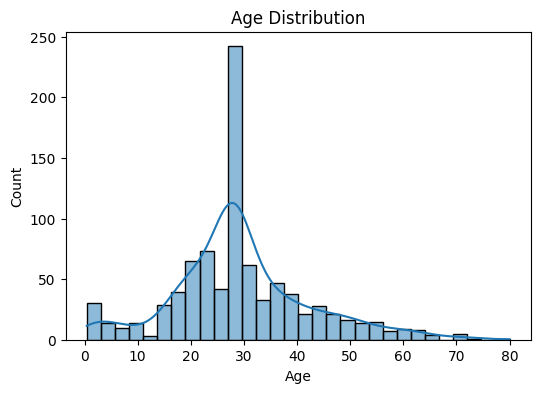

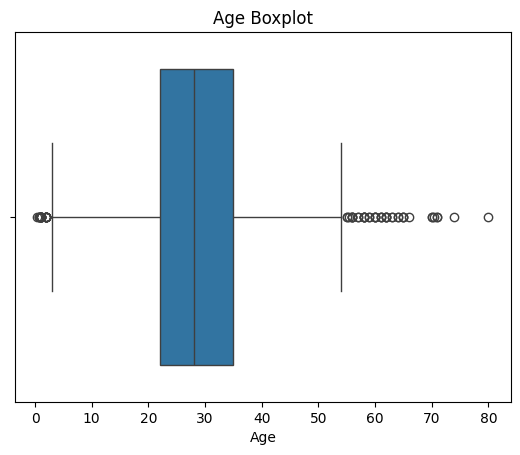

In [35]:
#d) Age Distribution Visualization
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

sns.boxplot(x=df['Age'])
plt.title("Age Boxplot")
plt.show()

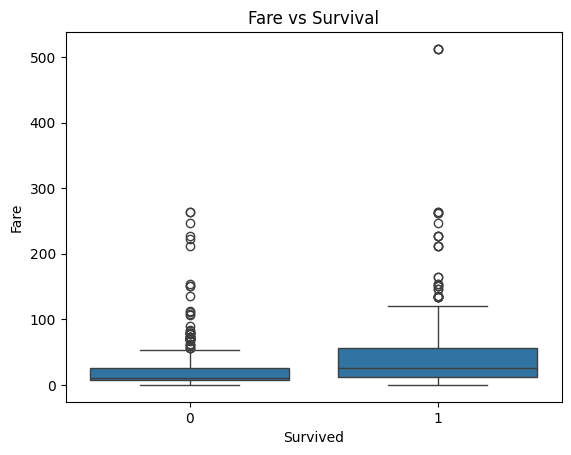

              Fare  Survived
Fare      1.000000  0.257307
Survived  0.257307  1.000000


In [36]:
#e) Correlation between Fare and Survival
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Fare vs Survival")
plt.show()

correlation = df[['Fare','Survived']].corr()
print(correlation)

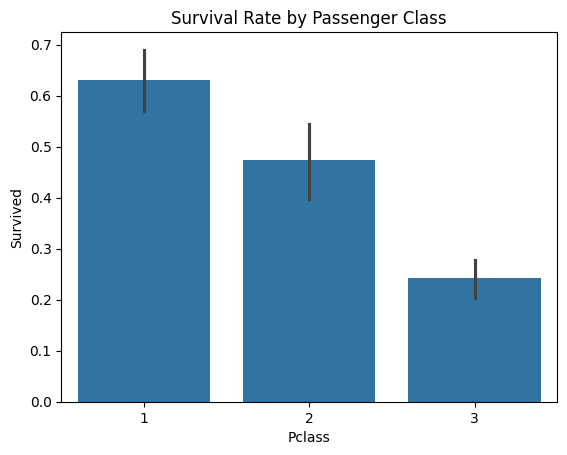

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [37]:
#f) Survival Rate by Passenger Class
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

print(df.groupby('Pclass')['Survived'].mean())

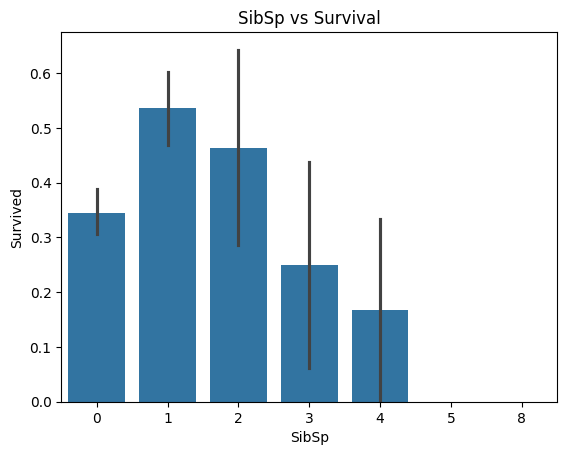

In [38]:
#g) Relationship Between Siblings/Spouses and Survival
sns.barplot(x='SibSp', y='Survived', data=df)
plt.title("SibSp vs Survival")
plt.show()

In [39]:
#h) Duplicate Records
duplicates = df.duplicated().sum()
print("Duplicate records:", duplicates)

Duplicate records: 0


In [40]:
df.drop_duplicates(inplace=True)

In [41]:
#i) Feature Engineering (FamilySize)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print(df[['SibSp','Parch','FamilySize']].head())

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


In [42]:
#j) Hypothesis Test (Male vs Female Survival)
male = df[df['Sex']=='male']['Survived']
female = df[df['Sex']=='female']['Survived']

t_stat, p_value = ttest_ind(male, female)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -19.297816550123354
P-value: 1.4060661308802594e-69


In [43]:
#Skewness and Kurtosis
print("Skewness:")
print(df.skew(numeric_only=True))

print("\nKurtosis:")
print(df.kurtosis(numeric_only=True))

Skewness:
PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Age            0.510245
SibSp          3.695352
Parch          2.749117
Fare           4.787317
FamilySize     2.727441
dtype: float64

Kurtosis:
PassengerId    -1.200000
Survived       -1.775005
Pclass         -1.280015
Age             0.993871
SibSp          17.880420
Parch           9.778125
Fare           33.398141
FamilySize      9.159666
dtype: float64


In [44]:
# Treat Outliers (Using IQR Method)
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df['Fare'] = np.where(df['Fare']>upper, upper, df['Fare'])
df['Fare'] = np.where(df['Fare']<lower, lower, df['Fare'])

In [45]:
# Final Missing Value Check
print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
dtype: int64
